In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.colors as mcolors
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
dataset_dir = 'ipl_2023_master_dataset/real_world_references'
cell_w, cell_h = 100, 75
LBP_RADIUS, LBP_POINTS = 1, 8

print("--- PHASE 1: TARGETED PLAYER FEATURE EXTRACTION (266-DIM) ---")
print("Loading OpenCV HOG Descriptor...")

# Initialize the standard HOG person detector
hog_detector = cv2.HOGDescriptor()
hog_detector.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

data_rows = []

for folder_name in sorted(os.listdir(dataset_dir)):
    folder_path = os.path.join(dataset_dir, folder_name)
    if not os.path.isdir(folder_path): continue
        
    try:
        team_id = int(folder_name.split('_')[0])
    except ValueError: continue
        
    print(f"Extracting targeted 266-Dim features from Team {team_id:02d} ({folder_name})...")
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))]
    
    for img_name in image_files:
        img_path = os.path.join(folder_path, img_name)
        try:
            # Read image and convert to grayscale for faster/better HOG detection
            pil_img = Image.open(img_path).convert('RGB').resize((800, 600))
            img_array = np.array(pil_img)
            gray_for_hog = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        except Exception: continue
        
        # 1. HOG BOUNDING BOX DETECTION
        global_human_mask = np.zeros((600, 800), dtype=bool)
        
        # Detect people. winStride and padding dictate speed vs accuracy. 
        # scale=1.05 is standard, but you can increase it to 1.1 for faster processing.
        boxes, weights = hog_detector.detectMultiScale(
            gray_for_hog, 
            winStride=(8, 8), 
            padding=(8, 8), 
            scale=1.05
        )
        
        # Create a boolean mask from the bounding boxes
        for (x, y, w, h) in boxes:
            # Clip coordinates to prevent going out of bounds
            x1, y1 = max(0, x), max(0, y)
            x2, y2 = min(800, x + w), min(600, y + h)
            global_human_mask[y1:y2, x1:x2] = True
        
        # 2. PRE-COMPUTE HSV/LBP
        hsv_array = mcolors.rgb_to_hsv(img_array / 255.0)
        gray_array = rgb2gray(img_array)
        lbp_array = local_binary_pattern(gray_array, LBP_POINTS, LBP_RADIUS, method='uniform')
        
        # 3. SLICE AND EXTRACT
        for row in range(8):
            for col in range(8):
                y1, y2 = row * cell_h, (row + 1) * cell_h
                x1, x2 = col * cell_w, (col + 1) * cell_w
                cell_id = f"c{(row * 8) + col + 1:02d}"
                
                cell_mask = global_human_mask[y1:y2, x1:x2]
                human_ratio = np.sum(cell_mask) / (cell_w * cell_h)
                
                # If at least 20% of the cell falls inside a HOG bounding box
                if human_ratio > 0.20:
                    valid_hsv = hsv_array[y1:y2, x1:x2][cell_mask]
                    valid_lbp = lbp_array[y1:y2, x1:x2][cell_mask]
                    if len(valid_hsv) == 0: continue
                        
                    # ---> 16 Bins for Hue = 256-Dim Color Vector <---
                    hist, _ = np.histogramdd(valid_hsv, bins=[16, 4, 4], range=[(0, 1), (0, 1), (0, 1)])
                    color_feat = hist.flatten() / (hist.flatten().sum() + 1e-7)
                    
                    # Extract 10-Dim Texture
                    lbp_hist, _ = np.histogram(valid_lbp.ravel(), bins=np.arange(0, LBP_POINTS + 3), range=(0, LBP_POINTS + 2))
                    lbp_feat = lbp_hist.astype(float) / (lbp_hist.sum() + 1e-7)
                    
                    # Concatenate to 266-Dim
                    final_features = np.concatenate((color_feat, lbp_feat))
                    
                    data_rows.append({
                        'Folder': folder_name,
                        'Team_ID': team_id,
                        'Image_Name': img_name,
                        'Cell_ID': cell_id,
                        'Features': final_features,
                        'Human_Ratio': human_ratio
                    })

df_dataset = pd.DataFrame(data_rows)
print(f"\nPhase 1 Complete! Extracted pure player signatures for {len(df_dataset)} cells.")
print("--> NOW GO RUN PHASE 2 AND PHASE 3 TO SAVE THE NEW PICKLE FILE! <--")

--- PHASE 1: TARGETED PLAYER FEATURE EXTRACTION (266-DIM) ---
Loading OpenCV HOG Descriptor...
Extracting targeted 266-Dim features from Team 10 (10_SRH)...
Extracting targeted 266-Dim features from Team 01 (1_CSK)...
Extracting targeted 266-Dim features from Team 02 (2_DC)...
Extracting targeted 266-Dim features from Team 03 (3_GT)...
Extracting targeted 266-Dim features from Team 04 (4_KKR)...
Extracting targeted 266-Dim features from Team 05 (5_LSG)...
Extracting targeted 266-Dim features from Team 06 (6_MI)...
Extracting targeted 266-Dim features from Team 07 (7_PBKS)...
Extracting targeted 266-Dim features from Team 08 (8_RR)...
Extracting targeted 266-Dim features from Team 09 (9_RCB)...

Phase 1 Complete! Extracted pure player signatures for 7641 cells.
--> NOW GO RUN PHASE 2 AND PHASE 3 TO SAVE THE NEW PICKLE FILE! <--


--- PHASE 1.5: FEATURE SPACE VISUALIZATION (t-SNE) ---
Running t-SNE on 3000 samples (Compressing 138-Dim -> 2-Dim)...
This might take a minute...


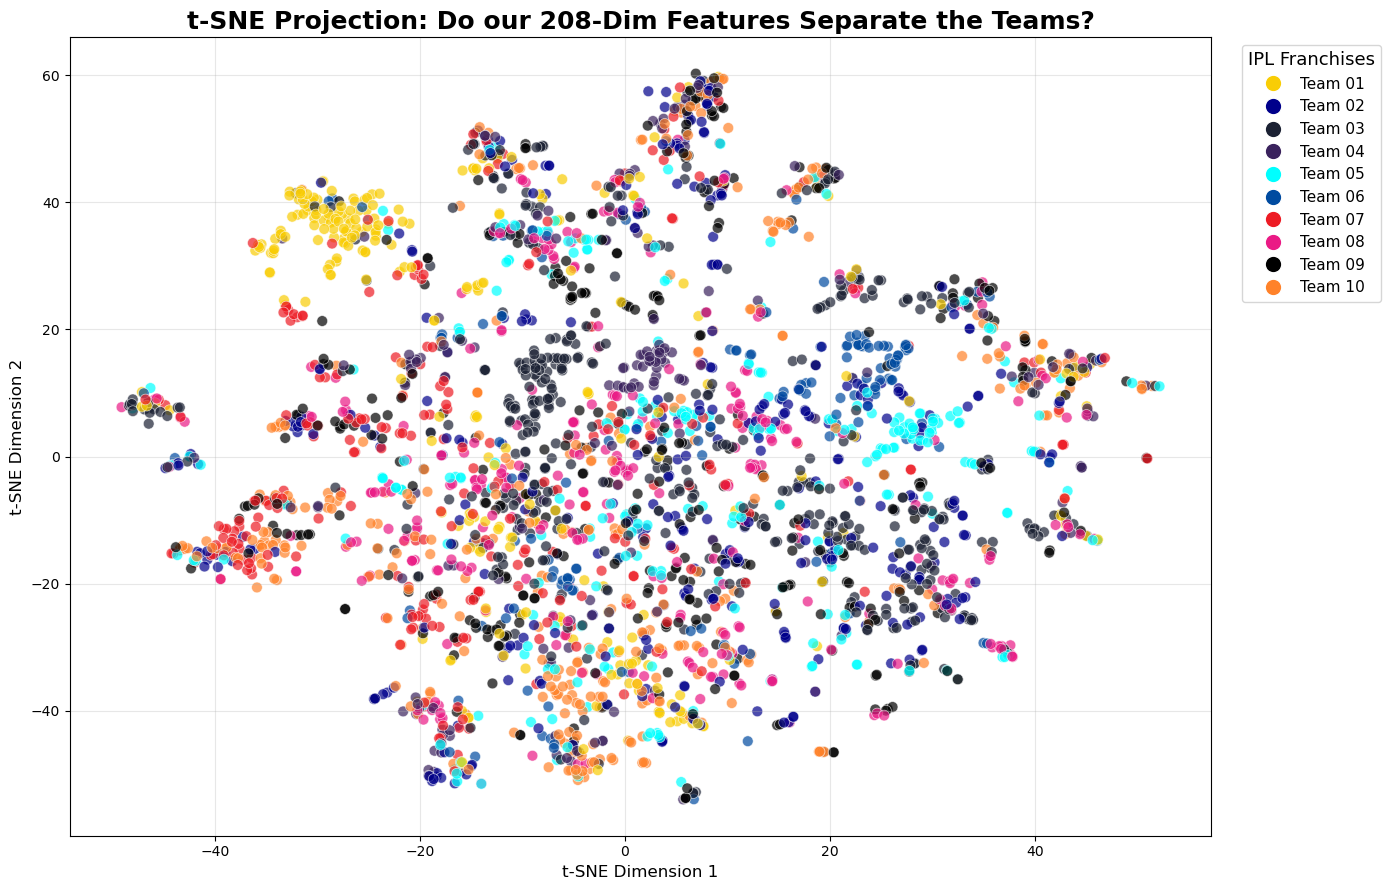

Visualization complete! Save this plot for your presentation slides.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

print("--- PHASE 1.5: FEATURE SPACE VISUALIZATION (t-SNE) ---")

# 1. Filter and Sample the Data
# t-SNE is computationally heavy. We will sample 3000 random player cells 
# to keep the notebook fast while still getting a beautiful plot.
df_tsne = df_dataset.copy()

# Optional: If you only want to plot the top teams, you can filter them here
if len(df_tsne) > 3000:
    df_tsne = df_tsne.sample(n=3000, random_state=42)

X_features = np.vstack(df_tsne['Features'].values)
y_labels = df_tsne['Team_ID'].values

print(f"Running t-SNE on {len(X_features)} samples (Compressing 138-Dim -> 2-Dim)...")
print("This might take a minute...")

# 2. Initialize and Fit t-SNE
# Perplexity of 30-50 is standard. PCA initialization makes it more stable.
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_features)

# 3. Visualization
plt.figure(figsize=(14, 9))

# Map team IDs to their actual IPL franchise colors for maximum presentation flair
ipl_colors = {
    1: '#F9CD05',  # CSK (Yellow)
    2: '#00008B',  # DC (Dark Blue)
    3: '#1B2133',  # GT (Navy)
    4: '#3A225D',  # KKR (Purple/Gold)
    5: '#00FFFF',  # LSG (Cyan)
    6: '#004BA0',  # MI (Blue)
    7: '#ED1B24',  # PBKS (Red)
    8: '#EA1A85',  # RR (Pink)
    9: '#000000',  # RCB (Black/Red - using black for contrast against PBKS)
    10: '#FF822A'  # SRH (Orange)
}

# Plot each point
scatter_colors = [ipl_colors.get(val, '#808080') for val in y_labels]
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=scatter_colors, alpha=0.7, edgecolors='white', linewidth=0.5, s=60)

# Create a custom legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=12, label=f'Team {tid:02d}') 
    for tid, color in ipl_colors.items() if tid in y_labels
]

plt.legend(handles=handles, title="IPL Franchises", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title_fontsize=13)
plt.title("t-SNE Projection: Do our 208-Dim Features Separate the Teams?", fontsize=18, fontweight='bold')
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete! Save this plot for your presentation slides.")

--- PHASE 2: EVALUATING OPTIMAL K PER TEAM ---

Analyzing Team 01 | Valid Cells: 691
  -> System selected Optimal K = 190 (DBI: 0.843)

Analyzing Team 02 | Valid Cells: 900
  -> System selected Optimal K = 195 (DBI: 1.059)

Analyzing Team 03 | Valid Cells: 1278
  -> System selected Optimal K = 190 (DBI: 1.043)

Analyzing Team 04 | Valid Cells: 511
  -> System selected Optimal K = 195 (DBI: 0.834)

Analyzing Team 05 | Valid Cells: 626
  -> System selected Optimal K = 195 (DBI: 0.914)

Analyzing Team 06 | Valid Cells: 427
  -> System selected Optimal K = 195 (DBI: 0.682)

Analyzing Team 07 | Valid Cells: 679
  -> System selected Optimal K = 195 (DBI: 0.909)

Analyzing Team 08 | Valid Cells: 740
  -> System selected Optimal K = 185 (DBI: 1.034)

Analyzing Team 09 | Valid Cells: 954
  -> System selected Optimal K = 190 (DBI: 1.118)

Analyzing Team 10 | Valid Cells: 835
  -> System selected Optimal K = 195 (DBI: 0.976)

Generating evaluation plots for your presentation...


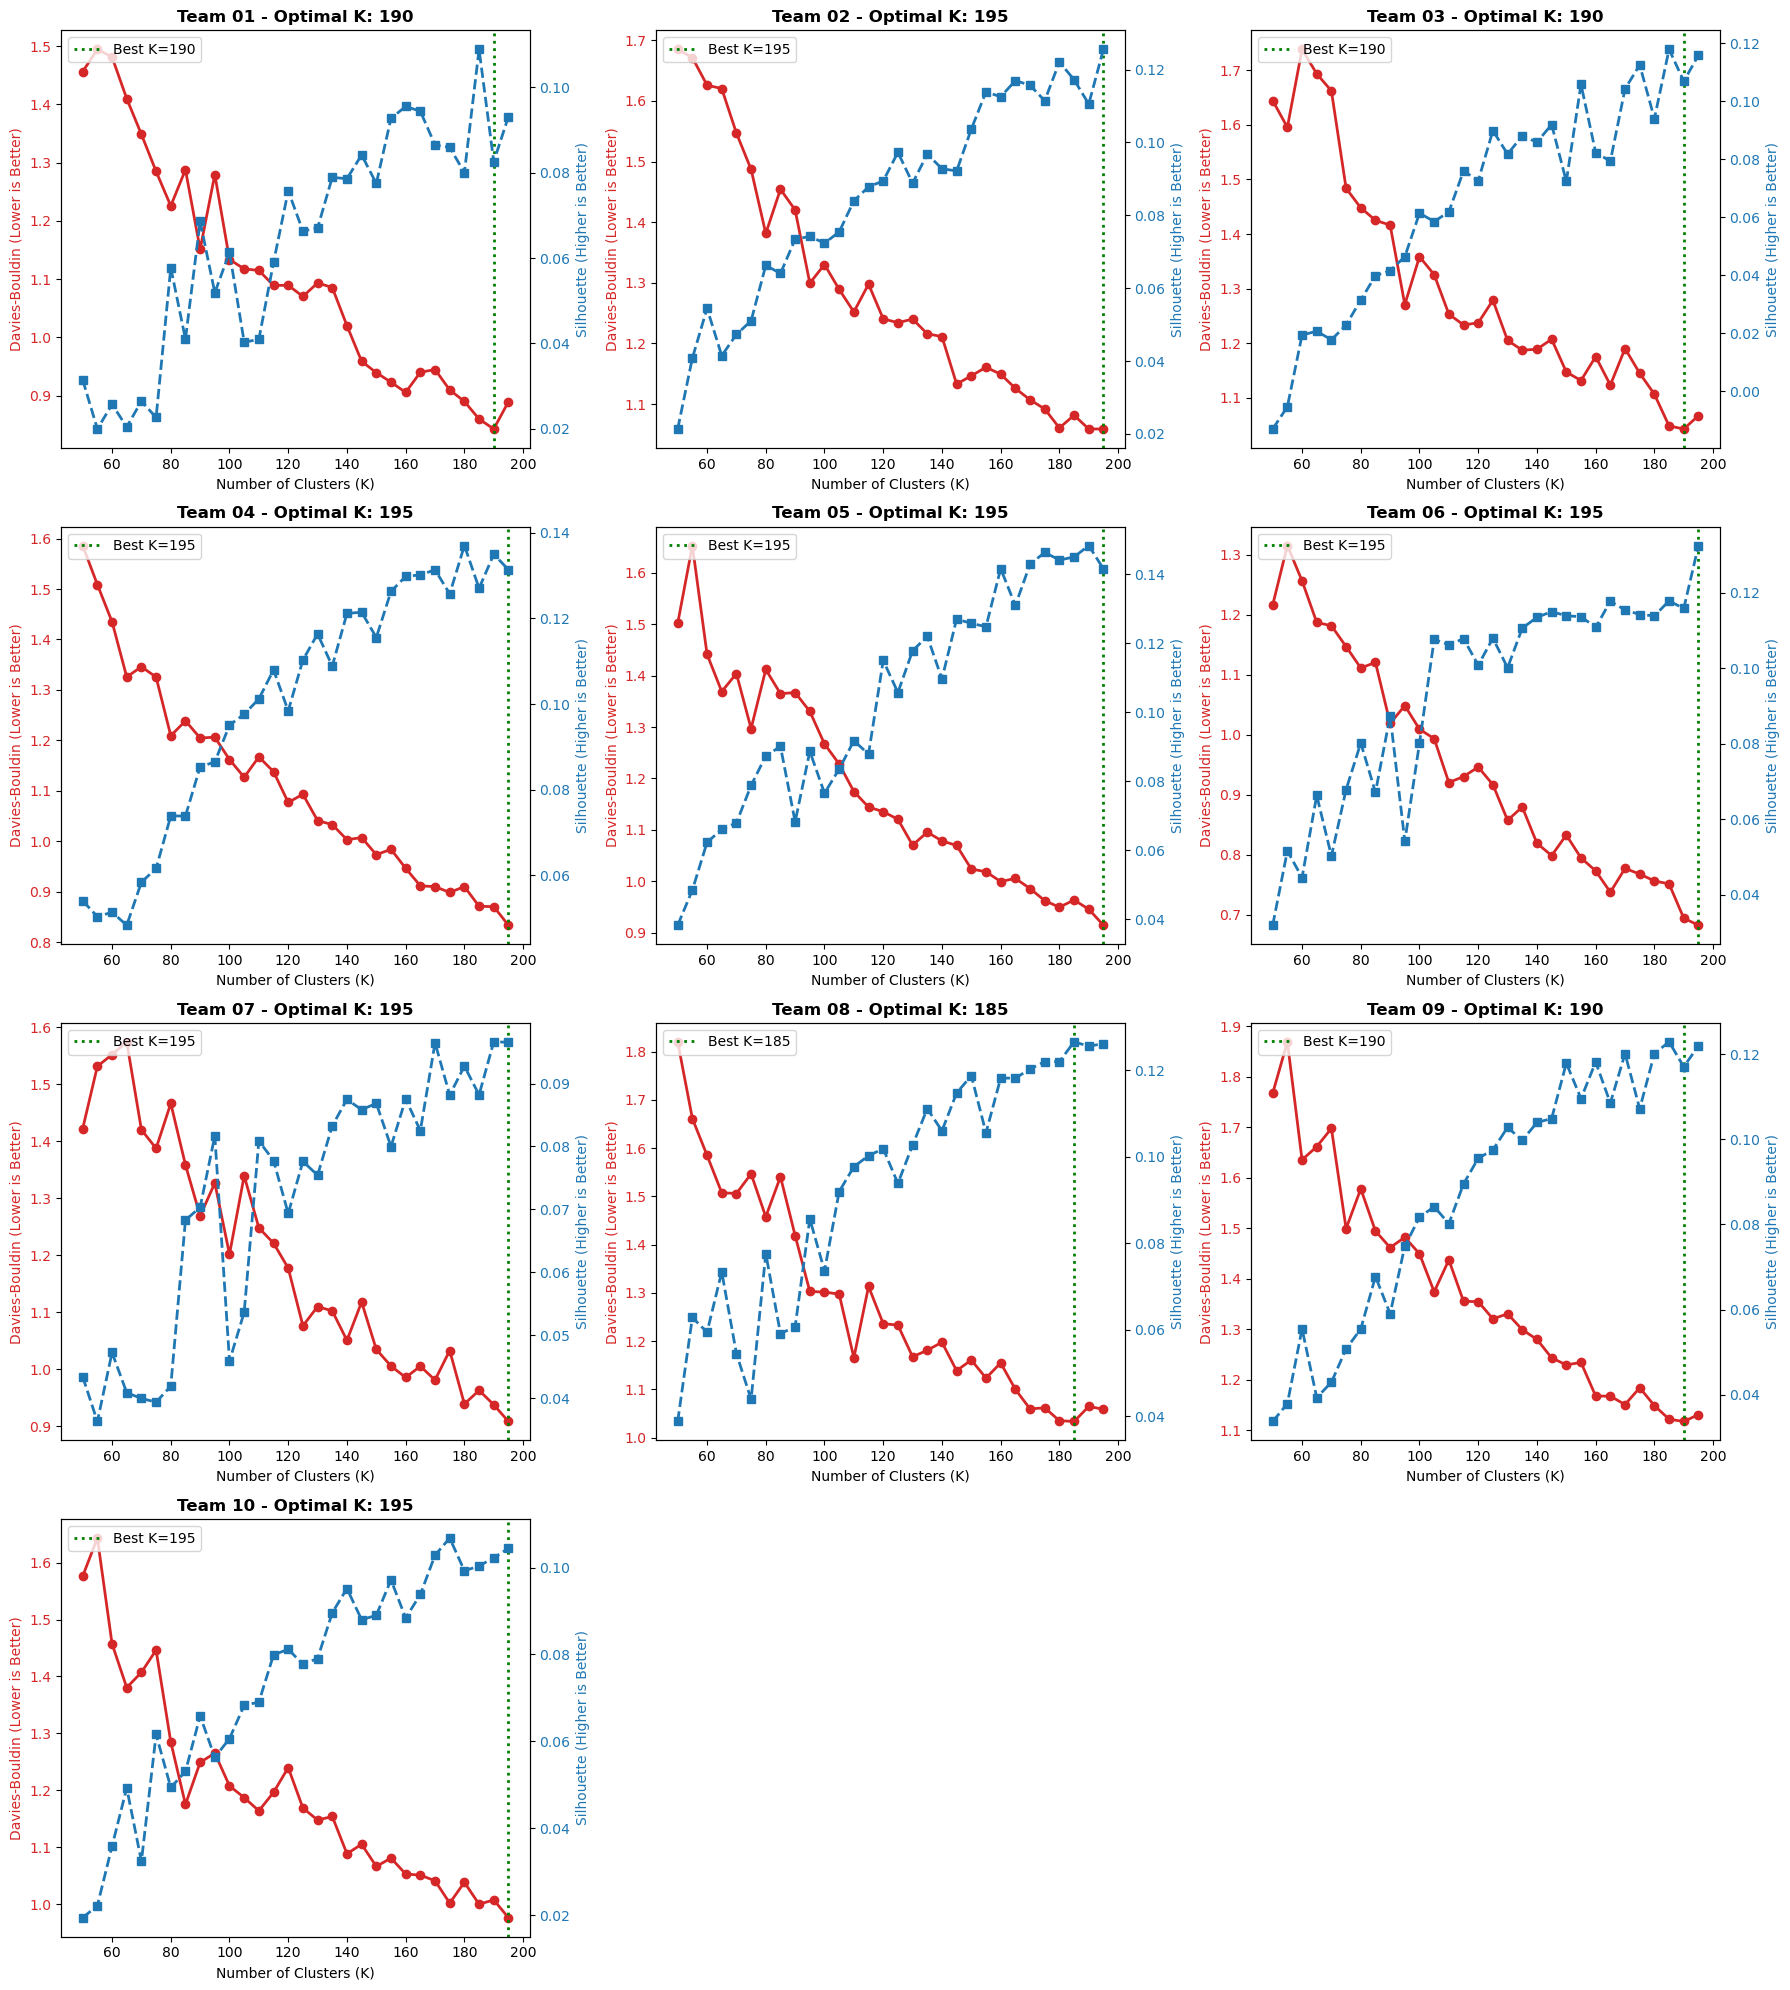

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler
import math
import warnings
warnings.filterwarnings('ignore')

print("--- PHASE 2: EVALUATING OPTIMAL K PER TEAM ---")

team_optimal_k = {}
team_metrics = {}

# Since we are looking inside a single team's folder, there are only a few 
# distinct variations (Jersey, Pants, Skin, Pads, Noise). A max of 12 is plenty.
k_range = range(50, 200,5)

# Get the list of unique teams we extracted in Phase 1
unique_teams = sorted(df_dataset['Team_ID'].unique())

for team_id in unique_teams:
    # 1. Isolate the features for just this one team
    team_data = df_dataset[df_dataset['Team_ID'] == team_id]
    X_team = np.vstack(team_data['Features'].values)
    
    print(f"\nAnalyzing Team {team_id:02d} | Valid Cells: {len(X_team)}")
    
    # Failsafe for extremely small folders
    if len(X_team) < max(k_range):
        print("  -> Not enough cells to cluster up to k=12. Skipping or truncating.")
        valid_k_range = range(2, len(X_team))
    else:
        valid_k_range = k_range
        
    # 2. Standardize Features (Crucial for HSV + LBP balance)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_team)
    
    dbi_scores = []
    sil_scores = []
    
    # 3. Test K values for this specific team
    for k in valid_k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
        labels = kmeans.fit_predict(X_scaled)
        
        dbi = davies_bouldin_score(X_scaled, labels)
        sil = silhouette_score(X_scaled, labels, random_state=42)
        
        dbi_scores.append(dbi)
        sil_scores.append(sil)
        
    # 4. Dynamically select the best K based on the lowest Davies-Bouldin Index
    best_k_idx = np.argmin(dbi_scores)
    optimal_k = valid_k_range[best_k_idx]
    
    team_optimal_k[team_id] = optimal_k
    team_metrics[team_id] = {
        'k_range': list(valid_k_range),
        'dbi': dbi_scores,
        'sil': sil_scores
    }
    
    print(f"  -> System selected Optimal K = {optimal_k} (DBI: {dbi_scores[best_k_idx]:.3f})")

# ==========================================
# VISUALIZATION: Plotting the curves for all teams
# ==========================================
print("\nGenerating evaluation plots for your presentation...")

num_teams = len(unique_teams)
cols = 3
rows = math.ceil(num_teams / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for idx, team_id in enumerate(unique_teams):
    ax1 = axes[idx]
    metrics = team_metrics[team_id]
    k_vals = metrics['k_range']
    
    color_dbi = 'tab:red'
    ax1.set_title(f"Team {team_id:02d} - Optimal K: {team_optimal_k[team_id]}", fontweight='bold')
    ax1.set_xlabel('Number of Clusters (K)')
    ax1.set_ylabel('Davies-Bouldin (Lower is Better)', color=color_dbi)
    ax1.plot(k_vals, metrics['dbi'], marker='o', color=color_dbi, linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color_dbi)
    
    ax2 = ax1.twinx()
    color_sil = 'tab:blue'
    ax2.set_ylabel('Silhouette (Higher is Better)', color=color_sil)
    ax2.plot(k_vals, metrics['sil'], marker='s', color=color_sil, linewidth=2, linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color_sil)
    
    # Highlight the optimal K
    best_k = team_optimal_k[team_id]
    ax1.axvline(x=best_k, color='green', linestyle=':', linewidth=2, label=f'Best K={best_k}')
    ax1.legend(loc='upper left')

# Hide any empty subplots
for i in range(num_teams, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

--- ALTERNATE PHASE 3: EXTRACTING PURE SIGNATURES FROM REFERENCE PNGS (266-DIM) ---
Successfully extracted base signature for Team 10 from 10_SRH_1.png
  -> Averaged additional signature for Team 10 from 10_SRH_2.png
  -> Averaged additional signature for Team 10 from 10_SRH_3.png
  -> Averaged additional signature for Team 10 from 10_SRH_4.png
  -> Averaged additional signature for Team 10 from 10_SRH_5.png
  -> Averaged additional signature for Team 10 from 10_SRH_6.png
  -> Averaged additional signature for Team 10 from 10_SRH_7.png
  -> Averaged additional signature for Team 10 from 10_SRH_8.png
Successfully extracted base signature for Team 01 from 1_CSK.png
  -> Averaged additional signature for Team 01 from 1_CSK_2.png
  -> Averaged additional signature for Team 01 from 1_CSK_3.png
  -> Averaged additional signature for Team 01 from 1_CSK_4.png
  -> Averaged additional signature for Team 01 from 1_CSK_5.png
Successfully extracted base signature for Team 02 from 2_DD_1.png
  -> A

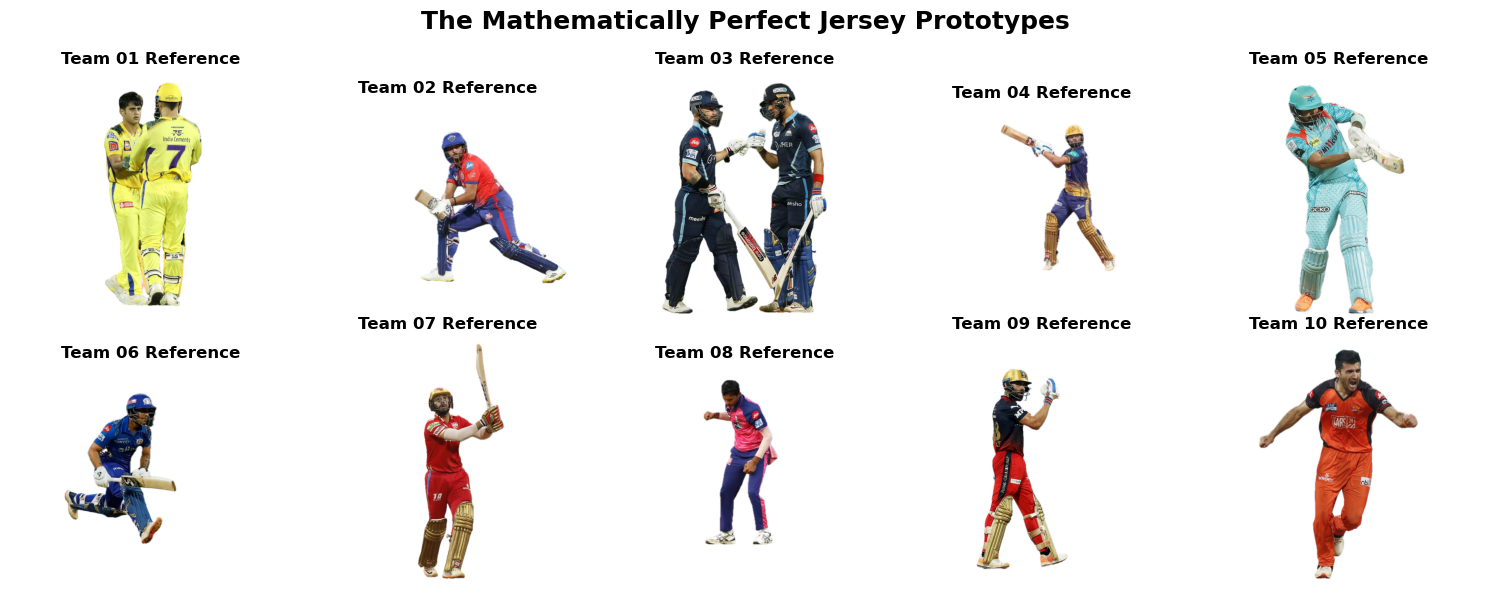

In [4]:
import os
import numpy as np
from PIL import Image
import matplotlib.colors as mcolors
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern
import pickle
import warnings
warnings.filterwarnings('ignore')

print("--- ALTERNATE PHASE 3: EXTRACTING PURE SIGNATURES FROM REFERENCE PNGS (266-DIM) ---")

def extract_pure_signature(png_path):
    # 1. Load image with the Alpha channel (RGBA)
    img_rgba = np.array(Image.open(png_path).convert('RGBA'))
    
    # 2. Extract RGB and the Alpha Mask
    img_rgb = img_rgba[:, :, :3]
    # The Alpha channel is [:,:,3]. Pixels > 0 are the actual jersey, 0 is transparent background!
    alpha_mask = img_rgba[:, :, 3] > 0  
    
    hsv_array = mcolors.rgb_to_hsv(img_rgb / 255.0)
    gray_array = rgb2gray(img_rgb)
    lbp_array = local_binary_pattern(gray_array, 8, 1, method='uniform')
    
    # --- 3. Pure Color Extraction ---
    valid_hsv = hsv_array[alpha_mask]
    if len(valid_hsv) == 0:
        return np.zeros((1, 266)) # Fallback if mask is somehow empty
        
    # ---> CRITICAL FIX: 16 Bins for Hue to match Phase 5 (266-Dim Total)
    hist, _ = np.histogramdd(valid_hsv, bins=[16, 4, 4], range=[(0, 1), (0, 1), (0, 1)])
    color_feat = hist.flatten() / (hist.flatten().sum() + 1e-7)
    
    # --- 4. Pure Texture Extraction ---
    valid_lbp = lbp_array[alpha_mask]
    lbp_hist, _ = np.histogram(valid_lbp.ravel(), bins=np.arange(0, 8 + 3), range=(0, 8 + 2))
    lbp_feat = lbp_hist.astype(float) / (lbp_hist.sum() + 1e-7)
    
    # Combine to 266-Dim
    return np.concatenate((color_feat, lbp_feat)).reshape(1, -1)

# ==========================================
# GENERATE AND SAVE NEW PROTOTYPES
# ==========================================
# Make sure this points to your folder containing '1_CSK_1.png', '2_DC_1.png', etc.
reference_dir = 'ipl_2022_master_dataset/reference_jerseys' 
new_team_prototypes = {}

if not os.path.exists(reference_dir):
    print(f"Error: Could not find folder '{reference_dir}'.")
else:
    for filename in sorted(os.listdir(reference_dir)):
        if filename.endswith('.png'):
            try:
                # Extracts the '1' from '1_CSK_1.png' or '1_CSK_2.png'
                team_id = int(filename.split('_')[0])
                png_path = os.path.join(reference_dir, filename)
                
                # Extract the 266-dim signature
                signature = extract_pure_signature(png_path)
                
                # If you have multiple images per team (like DC_1 and DC_2), average their vectors!
                if team_id in new_team_prototypes:
                    new_team_prototypes[team_id] = (new_team_prototypes[team_id] + signature) / 2.0
                    print(f"  -> Averaged additional signature for Team {team_id:02d} from {filename}")
                else:
                    new_team_prototypes[team_id] = signature
                    print(f"Successfully extracted base signature for Team {team_id:02d} from {filename}")
            except ValueError:
                continue

    # Overwrite the pickle file with your pure signatures
    model_filename = 'model_ipl_prototypes.pkl' # Change to model_GroupName.pkl before submission!
    with open(model_filename, 'wb') as f:
        pickle.dump(new_team_prototypes, f)
        
    print(f"\n Success! Overwrote '{model_filename}' with {len(new_team_prototypes)} pure, 266-Dim signatures.")
    print("You can now run Phase 5, and it will compare the real players against these perfect templates!")

import math
import matplotlib.pyplot as plt

# ==========================================
# PHASE 4: VISUALIZING THE REFERENCE PROTOTYPES
# ==========================================
print("\n--- PHASE 4: VISUALIZING THE LEARNED PROTOTYPES ---")

unique_teams = sorted(list(new_team_prototypes.keys()))
num_teams = len(unique_teams)
cols = 5
rows = math.ceil(num_teams / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
if type(axes) is np.ndarray:
    axes = axes.flatten()
else:
    axes = [axes]

for idx, team_id in enumerate(unique_teams):
    ax = axes[idx]
    
    # Find a matching reference PNG for this team from your folder
    matching_files = [f for f in os.listdir(reference_dir) if f.startswith(f"{team_id}_") and f.endswith('.png')]
    
    if matching_files:
        # Just grab the first matching jersey for the plot
        img_path = os.path.join(reference_dir, matching_files[0])
        try:
            # Load image and blend it over a white background so matplotlib displays it cleanly
            img_rgba = Image.open(img_path).convert('RGBA')
            background = Image.new('RGBA', img_rgba.size, (255, 255, 255))
            alpha_composite = Image.alpha_composite(background, img_rgba)
            
            ax.imshow(np.array(alpha_composite.convert('RGB')))
            ax.set_title(f"Team {team_id:02d} Reference", fontweight='bold', fontsize=12)
        except Exception as e:
            ax.text(0.5, 0.5, 'Image Error', ha='center', va='center')
    else:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
        
    ax.axis('off')

# Hide any unused subplots
for i in range(num_teams, len(axes)):
    axes[i].axis('off')

plt.suptitle("The Mathematically Perfect Jersey Prototypes", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

--- PHASE 5: BOX-LEVEL INFERENCE & GRABCUT MAPPING ---
Successfully loaded 10 team prototypes.

Testing on image: 6143_9126d4b5.jpg
Found 2 player(s). Evaluating full outfits...
  Player 1: Math Match -> T:2 (Score: 0.800)
  Player 2: Math Match -> T:2 (Score: 0.846)


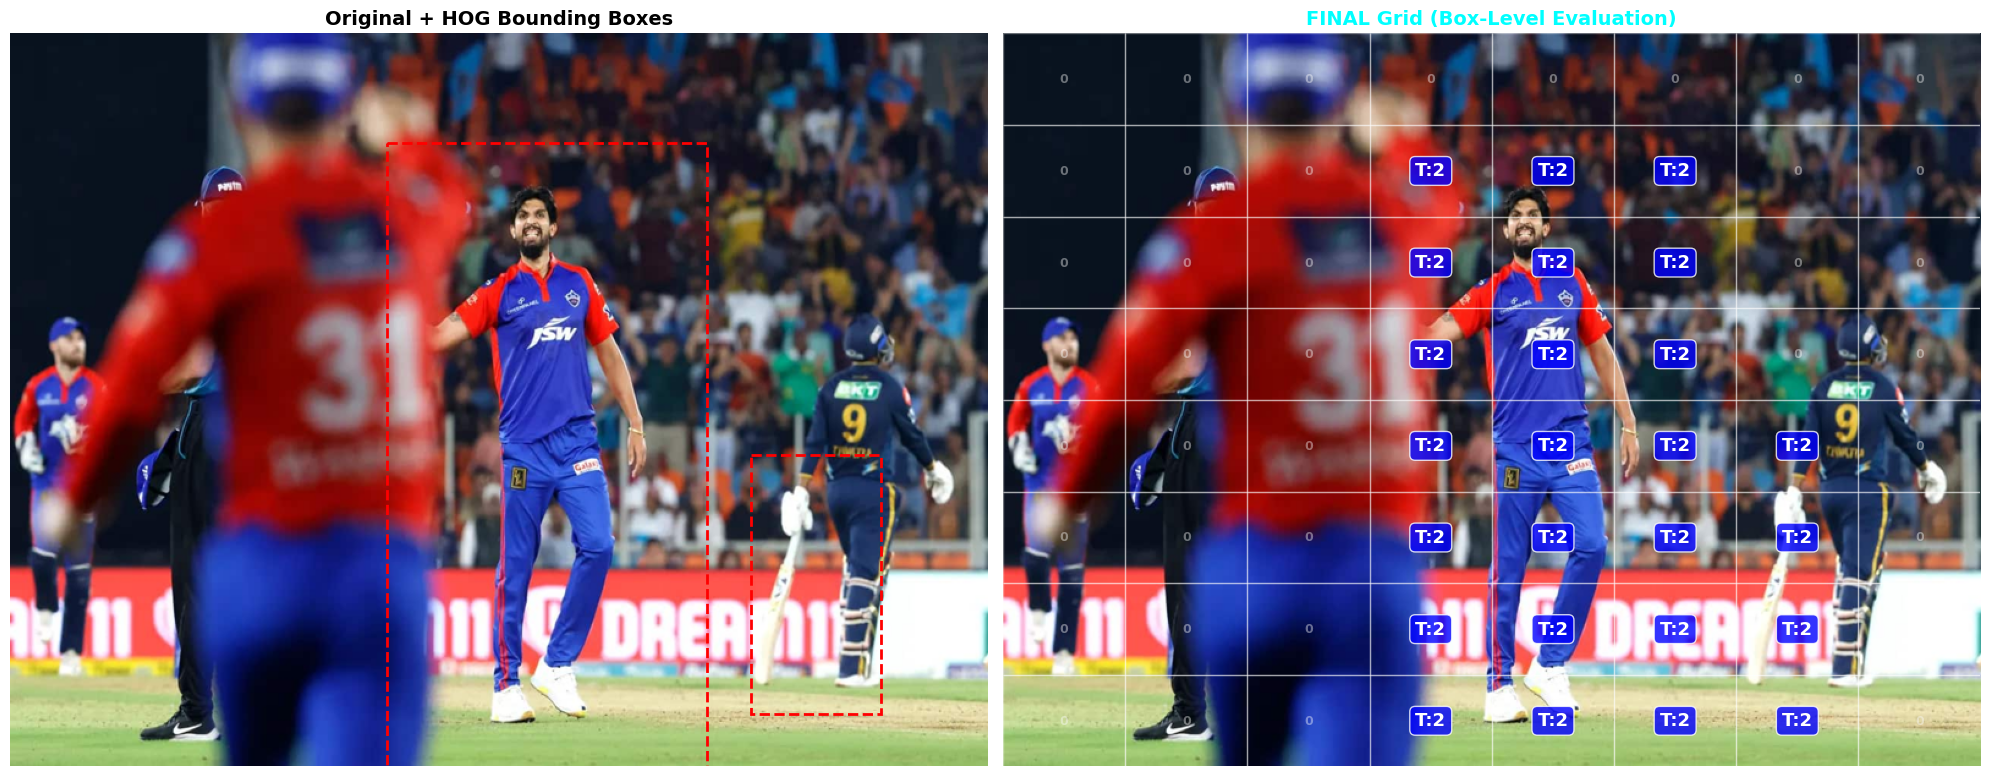


--- CSV ROW PREVIEW ---
6143_9126d4b5.jpg,Test,0,0,0,0,0,0,0,0,0,0,0,2,2,2,0,0,0,0,0,2,2,2,0,0,0,0,0,2,2,2,0,0,0,0,0,2,2,2,2,0,0,0,0,2,2,2,2,0,0,0,0,2,2,2,2,0,0,0,0,2,2,2,2,0


In [10]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
import warnings       

warnings.filterwarnings('ignore')

print("--- PHASE 5: BOX-LEVEL INFERENCE & GRABCUT MAPPING ---")

# ==========================================
# 1. LOAD THE LEARNED PROTOTYPES
# ==========================================
model_filename = 'model_ipl_prototypes.pkl'
try:
    with open(model_filename, 'rb') as f:
        team_prototypes = pickle.load(f)
    print(f"Successfully loaded {len(team_prototypes)} team prototypes.")
except FileNotFoundError:
    print(f"Error: '{model_filename}' not found. Please run Phase 3 first.")

ref_team_ids = list(team_prototypes.keys())
ref_signatures = np.vstack(list(team_prototypes.values()))

# ==========================================
# 2. SELECT TEST IMAGE & RUN HOG DETECTOR
# ==========================================
test_dir = 'ipl_2023_master_dataset/ipl2023'
test_images = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

if not test_images:
    print(f"No images found in {test_dir}.")
else:
    test_image_name = random.choice(test_images)
    img_path = os.path.join(test_dir, test_image_name)
    print(f"\nTesting on image: {test_image_name}")

    img_array = np.array(Image.open(img_path).convert('RGB').resize((800, 600)))
    
    hog = cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    
    boxes, weights = hog.detectMultiScale(img_array, winStride=(8, 8), padding=(8, 8), scale=1.05)
    
    player_boxes = []
    for (x, y, w, h) in boxes:
        player_boxes.append((x, y, x + w, y + h))
        
    print(f"Found {len(player_boxes)} player(s). Evaluating full outfits...")

    prediction_grid = np.zeros((8, 8), dtype=int)
    cell_w, cell_h = 100, 75
    LBP_RADIUS, LBP_POINTS = 1, 8
    CONFIDENCE_THRESHOLD = 0.65

    # ==========================================
    # 3. BOX-LEVEL FEATURE EXTRACTION
    # ==========================================
    for idx, (px1, py1, px2, py2) in enumerate(player_boxes):
        # 3.1 Setup Box and GrabCut Mask
        x_min, y_min = max(0, int(px1) - 5), max(0, int(py1) - 5)
        w = min(800 - x_min, int(px2 - px1) + 10)
        h = min(600 - y_min, int(py2 - py1) + 10)
        
        if w < 15 or h < 15:
            continue
            
        rect = (x_min, y_min, w, h)
        gc_mask = np.zeros((600, 800), np.uint8)
        bgModel = np.zeros((1, 65), np.float64)
        fgModel = np.zeros((1, 65), np.float64)
        
        try:
            cv2.grabCut(img_array, gc_mask, rect, bgModel, fgModel, 3, cv2.GC_INIT_WITH_RECT)
            fg_mask = ((gc_mask == 1) | (gc_mask == 3))[y_min:y_min+h, x_min:x_min+w]
        except Exception:
            fg_mask = np.ones((h, w), dtype=bool)

        # 3.2 Extract Box-Level Images
        box_rgb = img_array[y_min:y_min+h, x_min:x_min+w]
        box_hsv = mcolors.rgb_to_hsv(box_rgb / 255.0)
        box_gray = rgb2gray(box_rgb)
        box_lbp = local_binary_pattern(box_gray, LBP_POINTS, LBP_RADIUS, method='uniform')

        # 3.3 Math Signature Extraction
        predicted_team = 0
        flat_hsv = box_hsv[fg_mask]
        flat_lbp = box_lbp[fg_mask]
        
        if len(flat_hsv) > 50:
            vibrant_mask = (flat_hsv[:, 1] > 0.05) & (flat_hsv[:, 2] > 0.15)
            vibrant_pixels = flat_hsv[vibrant_mask]
            
            if len(vibrant_pixels) > 50:
                hist, _ = np.histogramdd(vibrant_pixels, bins=[16, 4, 4], range=[(0, 1), (0, 1), (0, 1)])
                color_feat = hist.flatten() / (hist.flatten().sum() + 1e-7)
                
                lbp_hist, _ = np.histogram(flat_lbp.ravel(), bins=np.arange(0, LBP_POINTS + 3), range=(0, LBP_POINTS + 2))
                lbp_feat = lbp_hist.astype(float) / (lbp_hist.sum() + 1e-7)
                
                box_signature = np.concatenate((color_feat, lbp_feat)).reshape(1, -1)
                
                similarities = cosine_similarity(box_signature, ref_signatures)[0]
                best_idx = np.argmax(similarities)
                if similarities[best_idx] >= CONFIDENCE_THRESHOLD:
                    predicted_team = ref_team_ids[best_idx]
                    print(f"  Player {idx+1}: Math Match -> T:{predicted_team} (Score: {similarities[best_idx]:.3f})")

        # 3.4 Map the winning team to all overlapping cells
        if predicted_team != 0:
            for r in range(8):
                for c in range(8):
                    y1, y2 = r * cell_h, (r + 1) * cell_h
                    x1, x2 = c * cell_w, (c + 1) * cell_w
                    
                    ix1, iy1 = max(x1, px1), max(y1, py1)
                    ix2, iy2 = min(x2, px2), min(y2, py2)
                    
                    if ix1 < ix2 and iy1 < iy2:
                        if ((ix2 - ix1) * (iy2 - iy1)) / (cell_w * cell_h) > 0.25:
                            prediction_grid[r, c] = predicted_team

    # ==========================================
    # 4. MAPPED GRID VISUALIZATION
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    axes[0].imshow(img_array)
    axes[0].set_title(f"Original + HOG Bounding Boxes", fontsize=14, fontweight='bold')
    axes[0].axis('off')
    for (px1, py1, px2, py2) in player_boxes:
        axes[0].add_patch(patches.Rectangle((px1, py1), px2-px1, py2-py1, linewidth=2, edgecolor='red', facecolor='none', linestyle='--'))

    axes[1].imshow(img_array)
    axes[1].set_title("FINAL Grid (Box-Level Evaluation)", fontsize=14, fontweight='bold', color='cyan')
    axes[1].axis('off')
    
    for r in range(8):
        for c in range(8):
            x_s, y_s = c * cell_w, r * cell_h
            axes[1].add_patch(patches.Rectangle((x_s, y_s), cell_w, cell_h, linewidth=1, edgecolor='white', facecolor='none', alpha=0.4))
            pid = prediction_grid[r, c]
            if pid != 0:
                axes[1].text(x_s + cell_w/2, y_s + cell_h/2, f"T:{pid}", color='white', fontweight='bold', fontsize=13, ha='center', va='center', bbox=dict(facecolor='blue', alpha=0.8, edgecolor='white', boxstyle='round,pad=0.3'))
            else:
                axes[1].text(x_s + cell_w/2, y_s + cell_h/2, "0", color='white', fontweight='bold', fontsize=9, ha='center', va='center', alpha=0.4)

    plt.tight_layout()
    plt.show()

    # ==========================================
    # 5. CSV FORMATTED OUTPUT PREVIEW
    # ==========================================
    flattened_output = prediction_grid.flatten().tolist()
    csv_format = f"{test_image_name},Test," + ",".join(map(str, flattened_output))
    print("\n--- CSV ROW PREVIEW ---")
    print(csv_format)

# For Bulk Updating in the dataset

In [11]:
# import os
# import cv2
# import numpy as np
# import pandas as pd
# from PIL import Image
# import matplotlib.colors as mcolors
# from skimage.color import rgb2gray
# from skimage.feature import local_binary_pattern
# from sklearn.metrics.pairwise import cosine_similarity
# import pickle
# import warnings
# from collections import Counter      
# from tqdm.notebook import tqdm   
# import io                        

# warnings.filterwarnings('ignore')

# print("--- PHASE 5: BULK INFERENCE (266-DIM + CELL MAPPING + EXCEL) ---")

# # ==========================================
# # 0. INITIALIZE MODELS
# # ==========================================
# print("Loading Models...")

# # Initialize OpenCV HOG Person Detector
# hog_detector = cv2.HOGDescriptor()
# hog_detector.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

# # Load your 266-dim prototypes
# with open('model_ipl_prototypes.pkl', 'rb') as f:
#     team_prototypes = pickle.load(f)
# ref_team_ids = list(team_prototypes.keys())
# ref_signatures = np.vstack(list(team_prototypes.values()))

# # ==========================================
# # 1. CONFIGURATION
# # ==========================================
# target_dir = 'ipl_2023_master_dataset/ipl2023'
# dataset_split = "Test" 
# output_csv = f"final_predictions_{dataset_split.lower()}.csv"
# output_xlsx = f"final_predictions_{dataset_split.lower()}.xlsx"

# all_image_files = sorted([f for f in os.listdir(target_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
# image_files = all_image_files 

# all_rows = []
# cell_w, cell_h = 100, 75
# LBP_POINTS = 8
# CONFIDENCE_THRESHOLD = 0.70

# print(f"Processing {len(image_files)} images...")

# # ==========================================
# # 2. BULK PROCESSING LOOP
# # ==========================================
# for idx, img_name in enumerate(tqdm(image_files, desc="Processing Images")):
#     img_path = os.path.join(target_dir, img_name)
#     img_array = np.array(Image.open(img_path).convert('RGB').resize((800, 600)))
    
#     # HOG Detection
#     boxes, weights = hog_detector.detectMultiScale(img_array, winStride=(8, 8), padding=(8, 8), scale=1.05)
    
#     # Convert (x, y, w, h) to (px1, py1, px2, py2) format
#     player_boxes = []
#     for (x, y, w, h) in boxes:
#         player_boxes.append((x, y, x + w, y + h))
    
#     # Pre-calculate Global Image features for speed
#     img_hsv = mcolors.rgb_to_hsv(img_array / 255.0)
#     img_gray = rgb2gray(img_array)
#     img_lbp = local_binary_pattern(img_gray, LBP_POINTS, 1, method='uniform')
    
#     # GrabCut Background Removal
#     master_grabcut_mask = np.zeros((600, 800), dtype=bool)
#     for (px1, py1, px2, py2) in player_boxes:
#         rect = (max(0, int(px1)-5), max(0, int(py1)-5), min(800, int(px2-px1)+10), min(600, int(py2-py1)+10))
#         try:
#             gc_mask = np.zeros((600, 800), np.uint8)
#             cv2.grabCut(img_array, gc_mask, rect, np.zeros((1, 65)), np.zeros((1, 65)), 3, cv2.GC_INIT_WITH_RECT)
#             master_grabcut_mask = np.logical_or(master_grabcut_mask, (gc_mask == 1) | (gc_mask == 3))
#         except: continue

#     prediction_grid = np.zeros((8, 8), dtype=int)
#     score_grid = np.zeros((8, 8), dtype=float)

#     # 2.1 Box-Level Feature Extraction & Grid Mapping
#     for (px1, py1, px2, py2) in player_boxes:
#         px1, py1, px2, py2 = int(px1), int(py1), int(px2), int(py2)
        
#         box_hsv = img_hsv[py1:py2, px1:px2]
#         box_lbp = img_lbp[py1:py2, px1:px2]
#         fg_mask = master_grabcut_mask[py1:py2, px1:px2]
        
#         predicted_team = 0
#         best_score = 0.0

#         # --- Math Signature Extraction ---
#         flat_hsv = box_hsv[fg_mask]
#         flat_lbp = box_lbp[fg_mask]
        
#         if len(flat_hsv) > 50:
#             vibrant_mask = (flat_hsv[:, 1] > 0.05) & (flat_hsv[:, 2] > 0.15)
#             vibrant_pixels = flat_hsv[vibrant_mask]
            
#             if len(vibrant_pixels) > 50:
#                 hist, _ = np.histogramdd(vibrant_pixels, bins=[16, 4, 4], range=[(0, 1), (0, 1), (0, 1)])
#                 color_feat = hist.flatten() / (hist.flatten().sum() + 1e-7)
                
#                 lbp_hist, _ = np.histogram(flat_lbp.ravel(), bins=np.arange(0, LBP_POINTS + 3), range=(0, LBP_POINTS + 2))
#                 lbp_feat = lbp_hist.astype(float) / (lbp_hist.sum() + 1e-7)
                
#                 box_signature = np.concatenate((color_feat, lbp_feat)).reshape(1, -1)
#                 similarities = cosine_similarity(box_signature, ref_signatures)[0]
#                 best_idx = np.argmax(similarities)
                
#                 if similarities[best_idx] >= CONFIDENCE_THRESHOLD:
#                     predicted_team = ref_team_ids[best_idx]
#                     best_score = similarities[best_idx]

#         # --- Map the winning team to all overlapping cells ---
#         if predicted_team != 0:
#             for r in range(8):
#                 for c in range(8):
#                     y1, y2 = r * cell_h, (r + 1) * cell_h
#                     x1, x2 = c * cell_w, (c + 1) * cell_w
                    
#                     ix1, iy1 = max(x1, px1), max(y1, py1)
#                     ix2, iy2 = min(x2, px2), min(y2, py2)
                    
#                     if ix1 < ix2 and iy1 < iy2:
#                         if ((ix2 - ix1) * (iy2 - iy1)) / (cell_w * cell_h) > 0.25:
#                             if best_score > score_grid[r, c]:
#                                 prediction_grid[r, c] = predicted_team
#                                 score_grid[r, c] = best_score

#     smoothed_grid = prediction_grid.copy()

#     # 2.2 Post-Process (Top 2 Teams Only & Min 5 Cells)
#     unique, counts = np.unique(smoothed_grid, return_counts=True)
#     valid_counts = {t: c for t, c in zip(unique, counts) if t != 0 and c >= 5}
#     if len(valid_counts) > 2:
#         top_2 = sorted(valid_counts, key=valid_counts.get, reverse=True)[:2]
#         smoothed_grid = np.where(np.isin(smoothed_grid, top_2), smoothed_grid, 0)
#     elif len(valid_counts) < len(unique) - 1:
#         valid_teams = list(valid_counts.keys())
#         smoothed_grid = np.where(np.isin(smoothed_grid, valid_teams), smoothed_grid, 0)
        
#     all_rows.append([img_name, dataset_split] + smoothed_grid.flatten().tolist())
    
#     if (idx+1) % 50 == 0: 
#         tqdm.write(f"  -> Processed {idx+1}/{len(image_files)} images...")

# # ==========================================
# # 3 & 4. EXPORT TO CSV AND EXCEL (IN CHUNKS)
# # ==========================================
# column_names = ['Image File Name', 'Train Or Test'] + [f'c{i:02d}' for i in range(1, 65)]
# df_final = pd.DataFrame(all_rows, columns=column_names)

# CHUNK_SIZE = 2000
# total_chunks = (len(df_final) // CHUNK_SIZE) + (1 if len(df_final) % CHUNK_SIZE != 0 else 0)

# print(f"\nSplitting output into {total_chunks} file(s) (Max {CHUNK_SIZE} rows per file)...")

# for chunk_idx in range(total_chunks):
#     start_idx = chunk_idx * CHUNK_SIZE
#     end_idx = min((chunk_idx + 1) * CHUNK_SIZE, len(df_final))
#     chunk_df = df_final.iloc[start_idx:end_idx]
    
#     part_num = chunk_idx + 1
    
#     chunk_csv = f"{output_csv.replace('.csv', '')}_part{part_num}.csv"
#     chunk_xlsx = f"{output_xlsx.replace('.xlsx', '')}_part{part_num}.xlsx"
    
#     chunk_df.to_csv(chunk_csv, index=False)
    
#     print(f"Generating Excel File Part {part_num}/{total_chunks}: {chunk_xlsx}...")
#     writer = pd.ExcelWriter(chunk_xlsx, engine='xlsxwriter')
#     chunk_df.to_excel(writer, index=False, sheet_name='Predictions')

#     worksheet = writer.sheets['Predictions']
#     worksheet.set_default_row(60)

#     for local_idx, (orig_idx, row) in enumerate(chunk_df.iterrows()):
#         img_name = row['Image File Name']
#         img_path = os.path.join(target_dir, img_name)
        
#         if os.path.exists(img_path):
#             img = Image.open(img_path).resize((80, 60))
            
#             image_stream = io.BytesIO()
#             img.save(image_stream, format='PNG')
#             image_stream.seek(0)
            
#             worksheet.insert_image(local_idx + 1, 66, img_name, {'image_data': image_stream, 'x_scale': 1, 'y_scale': 1})

#     writer.close()
#     print(f" Saved: {chunk_xlsx}")

# # ==========================================
# # 5. EXPORT THE PROCESSED IMAGE LIST
# # ==========================================
# processed_list_filename = f"processed_images_list_2023_{dataset_split.lower()}.txt"
# with open(processed_list_filename, 'w') as f:
#     for img_name in df_final['Image File Name']:
#         f.write(f"{img_name}\n")

# print(f"\nProcessing Complete! Successfully evaluated {len(df_final)} images across {total_chunks} files.")
# print(f"Full list of processed images saved to: '{processed_list_filename}'")